In [1]:
import pandas as pd
import numpy as np
import os
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import torch
from transformers import AutoTokenizer, AutoModel
import torch.nn as nn
from torch.optim import AdamW
from torch.nn import BCEWithLogitsLoss
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report, roc_curve, auc
from peft import LoraConfig, get_peft_model  # For efficient fine-tuning



e:\ML\BioActivity\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df=pd.read_excel("E:\\ML\\BioActivity\\bioactivity_dataset_cleaned_new_v3.xlsx", sheet_name="Sheet1")
df.head(3)

,canonical_smiles,MW,LogP,NumHDonors,TPSA,NumRotatableBonds,bioactivity
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,129.65,11,1
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,133.31,10,1
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4,107.53,7,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5494 entries, 0 to 5493
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   canonical_smiles   5494 non-null   object 
 1   MW                 5494 non-null   float64
 2   LogP               5494 non-null   float64
 3   NumHDonors         5494 non-null   int64  
 4   TPSA               5494 non-null   float64
 5   NumRotatableBonds  5494 non-null   int64  
 6   bioactivity        5494 non-null   int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 300.6+ KB


In [4]:
df.iloc[0]['canonical_smiles']

'O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc12)NO'

In [5]:
df['bioactivity'].value_counts()

bioactivity
1    4326
0    1168
Name: count, dtype: int64

In [6]:
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit.Chem import rdFingerprintGenerator
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_recall_curve
import numpy as np
import random
import warnings
warnings.filterwarnings("ignore")

# -------------------------------
# CONFIG (Fixed)
# -------------------------------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_LEN = 512
BATCH_SIZE = 32
ECFP_BITS = 1024
ECFP_RADIUS = 2
AUGMENT_TRAIN = True


train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['bioactivity'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

scaler=StandardScaler().fit(train_df[['MW', 'LogP', 'NumHDonors', 'TPSA', 'NumRotatableBonds']])

# -------------------------------
# SMILES Augmentation
# -------------------------------
def random_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return smiles
    return Chem.MolToSmiles(mol, doRandom=True, canonical=False)

# -------------------------------
# ECFP Generator
# -------------------------------
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=ECFP_RADIUS, fpSize=ECFP_BITS)
def get_ecfp(smiles, radius=ECFP_RADIUS, n_bits=ECFP_BITS):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(n_bits, dtype=np.float32)
    fp = morgan_gen.GetFingerprint(mol)
    arr = np.zeros((n_bits,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

# -------------------------------
# Dataset
# -------------------------------

tokenizer = AutoTokenizer.from_pretrained('ibm/MoLFormer-XL-both-10pct', trust_remote_code=True)

class BioActivityDataset(Dataset):
    def __init__(self, df, tokenizer, scaler=None, ecfp_cache=None, augment=False):
        self.smiles = df['canonical_smiles'].values.tolist()
        self.desc   = df[['MW', 'LogP', 'NumHDonors', 'TPSA', 'NumRotatableBonds']].values.astype(np.float32)
        self.labels = df['bioactivity'].values.astype(np.float32)
        self.encodings = tokenizer(self.smiles, truncation=True, padding=True, max_length=512, return_tensors='pt')
        self.augment = augment
        self.max_len = MAX_LEN

        
        if scaler is None:
            self.scaler = StandardScaler().fit(self.desc)
        else:
            self.scaler = scaler
        self.desc = self.scaler.transform(self.desc)
        
        print("Computing ECFP...")
        self.ecfp = np.stack([get_ecfp(s) for s in self.smiles])
        

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx): 
        item = {k: v[idx] for k, v in self.encodings.items()}

        item['ecfp']=torch.tensor(self.ecfp[idx])
        item['descriptors']=torch.tensor(self.desc[idx])
        item['labels']=torch.tensor(self.labels[idx])

        return item

# -------------------------------
# Collate Function
# -------------------------------
def collate_fn(batch):
    return {
        'input_ids': torch.stack([b['input_ids'] for b in batch]),
        'attention_mask': torch.stack([b['attention_mask'] for b in batch]),
        'descriptors': torch.stack([b['descriptors'] for b in batch]),
        'ecfp': torch.stack([b['ecfp'] for b in batch]),
        'labels': torch.tensor([b['labels'] for b in batch], dtype=torch.float)
    }



In [15]:
train_dataset = BioActivityDataset(train_df, tokenizer, scaler=scaler)
val_dataset = BioActivityDataset(val_df, tokenizer, scaler=scaler)
test_dataset = BioActivityDataset(test_df, tokenizer, scaler=scaler)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

Computing ECFP...
Computing ECFP...
Computing ECFP...


In [7]:
train_df['bioactivity'].value_counts(), val_df['bioactivity'].value_counts(), test_df['bioactivity'].value_counts()

(bioactivity
 1    3028
 0     817
 Name: count, dtype: int64,
 bioactivity
 1    645
 0    179
 Name: count, dtype: int64,
 bioactivity
 1    653
 0    172
 Name: count, dtype: int64)

#### ECFP + BERT embedding based model

In [7]:
# -------------------------------
# Model
# -------------------------------
class FineTunedBERTaECFP(nn.Module):
    def __init__(self, ecfp_bits=ECFP_BITS, n_descriptors=5, unfreeze_layers=12, num_heads=8, 
                 dropout=0.3, hidden_dim=768, num_classifier_layers=4, 
                 fusion_type='gated'):
        super().__init__()
        self.bert = AutoModel.from_pretrained("ibm/MoLFormer-XL-both-10pct", trust_remote_code=True)

        # Unfreeze last N layers
        for p in self.bert.parameters():
            p.requires_grad = False
        for layer in self.bert.encoder.layer[-unfreeze_layers:]:
            for p in layer.parameters():
                p.requires_grad = True

        # Project ECFP and descriptors to 768
        self.ecfp_proj = nn.Sequential(
            nn.Linear(ecfp_bits, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(512, 768),
            nn.LayerNorm(768),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.desc_proj = nn.Sequential(
            nn.Linear(n_descriptors, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(512, 768),
            nn.LayerNorm(768),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        # Attention
        self.attn = nn.MultiheadAttention(768, num_heads=num_heads, batch_first=True, dropout=dropout*0.5)
        self.attn_norm = nn.LayerNorm(768)

        self.fusion_type = fusion_type
        if fusion_type == 'gated':
            self.gate = nn.Sequential(
                nn.Linear(768 * 3, 768),
                nn.Sigmoid()
            )
            self.fusion_proj = nn.Linear(768 * 3, 768)
        elif fusion_type == 'bilinear':
            self.bilinear = nn.Bilinear(768, 768, 768)

        # Classifier
        classifier_layers = []
        in_dim = 768 * 3 if fusion_type == 'concat' else 768
        
        for i in range(num_classifier_layers):
            out_dim = hidden_dim // (2 ** i)
            classifier_layers.extend([
                nn.Linear(in_dim, out_dim),
                nn.LayerNorm(out_dim),
                nn.GELU(),
                nn.Dropout(dropout if i < num_classifier_layers - 1 else dropout * 0.5)
            ])
            in_dim = out_dim
        
        classifier_layers.append(nn.Linear(in_dim, 1))
        self.classifier = nn.Sequential(*classifier_layers)


    def forward(self, input_ids, attention_mask, ecfp, descriptors):
        # SMILES
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        
        cls_ = out.last_hidden_state[:,0]
        mean_pool = out.last_hidden_state.mean(dim=1)  # [B,768]
        max_pool = out.last_hidden_state.max(dim=1)[0]
        smiles = (cls_ + mean_pool + max_pool) / 3

        # ECFP + Desc
        ecfp_emb = self.ecfp_proj(ecfp)             # [B,768]
        desc_emb = self.desc_proj(descriptors)      # [B,768]

        # Attention
        q = torch.stack([ecfp_emb, desc_emb], dim=1)  # [B,2,768]
        kv = smiles.unsqueeze(1)                       # [B,1,768]
        attn_out, attn_weights = self.attn(q, kv, kv)             # [B,2,768]

        ecfp_attn = self.attn_norm(attn_out[:,0] + ecfp_emb)    # [B,768]
        desc_attn = self.attn_norm(attn_out[:,1] + desc_emb)   # [B,768]

        # Fuse
        if self.fusion_type == 'concat':
            fused = torch.cat([smiles, ecfp_attn, desc_attn], dim=1)
        elif self.fusion_type == 'gated':
            concat = torch.cat([smiles, ecfp_attn, desc_attn], dim=1)
            gate = self.gate(concat)
            fused = gate * self.fusion_proj(concat)
        else:  # bilinear
            fused = self.bilinear(smiles, ecfp_attn + desc_attn)
        
        return self.classifier(fused).squeeze(-1)

model = FineTunedBERTaECFP(unfreeze_layers=12, num_heads=8)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

FineTunedBERTaECFP(
  (bert): MolformerModel(
    (embeddings): MolformerEmbeddings(
      (word_embeddings): Embedding(2362, 768, padding_idx=2)
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (encoder): MolformerEncoder(
      (layer): ModuleList(
        (0-11): 12 x MolformerLayer(
          (attention): MolformerAttention(
            (self): MolformerSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (rotary_embeddings): MolformerRotaryEmbedding()
              (feature_map): MolformerFeatureMap(
                (kernel): ReLU()
              )
            )
            (output): MolformerSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
              (d

#### V2 Architecture: Cross-Modal Transformer + MACCS Keys + Expanded Descriptors

In [8]:

# ─────────────────────────────────────────────────────────────────────────────
# V2: Extended Features + Dataset + FocalLoss + Model
#
# Improvements over v1:
#   1. Attention pooling over SMILES token sequence (learned weights)
#   2. MACCS keys (167-bit) as a 4th modality
#   3. 6 Lipinski Rule-of-Five descriptors (MW, LogP, HBD, HBA, TPSA, RotBonds)
#   4. Cross-modal Transformer (Pre-LN): all 4 modalities attend to each other
#   5. FocalLoss with label smoothing — targets hard boundary examples
#   6. On-the-fly SMILES augmentation (random non-canonical strings)
# ─────────────────────────────────────────────────────────────────────────────
import torch.nn.functional as F
from rdkit.Chem import MACCSkeys

MACCS_BITS        = 167
N_DESCRIPTORS_EXT = 5   # Lipinski RO5: MW, LogP, HBD, HBA, TPSA, RotBonds

def compute_extended_descriptors(smiles):
    """Lipinski Rule-of-Five + TPSA + RotBonds (5 descriptors)."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(N_DESCRIPTORS_EXT, dtype=np.float32)
    try:
        return np.array([
            Descriptors.MolWt(mol),              # MW      ≤ 500
            Descriptors.MolLogP(mol),            # LogP    ≤ 5
            Descriptors.NumHDonors(mol),         # HBD     ≤ 5
            Descriptors.TPSA(mol),               # TPSA    < 140
            Descriptors.NumRotatableBonds(mol),  # RotBond ≤ 10
        ], dtype=np.float32)
    except Exception:
        return np.zeros(N_DESCRIPTORS_EXT, dtype=np.float32)

def get_maccs(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(MACCS_BITS, dtype=np.float32)
    fp  = MACCSkeys.GenMACCSKeys(mol)
    arr = np.zeros((MACCS_BITS,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


# ── Dataset ───────────────────────────────────────────────────────────────────
class BioActivityDataset_v2(Dataset):
    def __init__(self, df, tokenizer, scaler=None, augment=False):
        self.tokenizer = tokenizer          # kept for on-the-fly augmentation
        self.smiles    = df['canonical_smiles'].values.tolist()
        self.labels    = df['bioactivity'].values.astype(np.float32)
        self.augment   = augment
        # padding='max_length' ensures consistency with on-the-fly tokenised augmentations
        self.encodings = tokenizer(
            self.smiles, truncation=True, padding='max_length',
            max_length=512, return_tensors='pt'
        )
        raw_desc = np.stack([compute_extended_descriptors(s) for s in self.smiles])
        if scaler is None:
            self.scaler = StandardScaler().fit(raw_desc)
        else:
            self.scaler = scaler
        self.desc  = self.scaler.transform(raw_desc).astype(np.float32)
        print("Computing ECFP...")
        self.ecfp  = np.stack([get_ecfp(s)  for s in self.smiles])
        #print("Computing MACCS...")
        #self.maccs = np.stack([get_maccs(s) for s in self.smiles])

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        # 50% chance: re-tokenise a random non-canonical SMILES string
        if self.augment and random.random() < 0.5:
            aug_smi = random_smiles(self.smiles[idx])
            enc     = self.tokenizer(
                [aug_smi], truncation=True, padding='max_length',
                max_length=512, return_tensors='pt'
            )
            item = {k: v[0] for k, v in enc.items()}
        else:
            item = {k: v[idx] for k, v in self.encodings.items()}
        item['ecfp']        = torch.tensor(self.ecfp[idx])
        #item['maccs']       = torch.tensor(self.maccs[idx])
        item['descriptors'] = torch.tensor(self.desc[idx])
        item['labels']      = torch.tensor(self.labels[idx])
        return item

def collate_fn_v2(batch):
    return {
        'input_ids':      torch.stack([b['input_ids']      for b in batch]),
        'attention_mask': torch.stack([b['attention_mask'] for b in batch]),
        'ecfp':           torch.stack([b['ecfp']           for b in batch]),
        #'maccs':          torch.stack([b['maccs']          for b in batch]),
        'descriptors':    torch.stack([b['descriptors']    for b in batch]),
        'labels':         torch.tensor([b['labels']        for b in batch], dtype=torch.float),
    }


# ── Focal Loss with label smoothing ───────────────────────────────────────────
class FocalLoss(nn.Module):
    """
    Binary Focal Loss with label smoothing.

    Intuition
    ---------
    Standard BCE penalises every error equally. When the model is very
    confident and correct (p ≈ 1 for a positive), the gradient is tiny
    anyway — but it still wastes capacity. Focal loss multiplies by
    (1-p)^gamma, so easy well-classified examples contribute almost
    nothing to training and the model focuses its capacity on the hard
    boundary cases that cause the accuracy plateau.

      alpha   : upweight for positives  (≈ class_neg / class_pos)
      gamma   : focusing exponent       (0 = plain BCE, 2 = standard focal)
      smoothing: label smoothing ε      (prevents overconfident logits)
    """
    def __init__(self, alpha=0.75, gamma=2.0, smoothing=0.05):
        super().__init__()
        self.alpha     = alpha
        self.gamma     = gamma
        self.smoothing = smoothing

    def forward(self, logits, targets):
        y    = targets * (1 - self.smoothing) + 0.5 * self.smoothing   # smooth labels
        bce  = F.binary_cross_entropy_with_logits(logits, y, reduction='none')
        pt   = torch.exp(-bce)                                          # p_correct
        a_t  = self.alpha * targets + (1 - self.alpha) * (1 - targets) # per-sample alpha
        loss = a_t * (1 - pt) ** self.gamma * bce
        return loss.mean()


#### V3 Architecture

In [9]:

# ─────────────────────────────────────────────────────────────────────────────
# V3 Architecture — 3-modality version (MACCS removed)
#
# Modalities: SMILES (MoLFormer) + ECFP (1024-bit) + Descriptors (5 Lipinski)
# MACCS (167-bit) removed — ECFP already captures most of its signal and
# removing it reduces parameters, simplifies the cross-modal attention, and
# eliminates the redundant modality token from fusion.
#
# Changes from 4-modality version:
#   - maccs_proj removed
#   - modal_type_embed: Embedding(4,D) → Embedding(3,D)
#   - fusion_proj input: D*4 → D*3  (3072 → 2304)  [gated mode]
#   - forward(): maccs arg removed, 3-token stack
#
# Structural fixes retained from previous version:
#   FIX-A: desc_proj — single stage (5→768)
#   FIX-B: Gate — D→D//8→D bottleneck  [gated mode]
#   FIX-C: fusion_proj — GELU+LayerNorm after linear  [gated mode]
#   FIX-D: Learnable SMILES pooling weights
#   FIX-E: activation='gelu' in cross-modal transformer
#   FIX-F: dim_feedforward=D*2 (not D*4 — only 3 tokens)
#   FIX-G: Freeze ALL BERT params first, then unfreeze top layers
#           (prevents embedding layer being trained by default)
#   NEW  : fusion_type='bilinear' option — nn.Bilinear(smiles, ecfp+desc)
#   NEW  : hidden_dim now controls classifier first-layer size
# ─────────────────────────────────────────────────────────────────────────────
import torch.nn.functional as F

class FineTunedBERTaECFP_v3(nn.Module):
    def __init__(
        self,
        ecfp_bits             = ECFP_BITS,
        n_descriptors         = N_DESCRIPTORS_EXT,
        num_heads             = 8,
        dropout               = 0.2,
        hidden_dim            = 512,
        num_classifier_layers = 4,
        n_cross_layers        = 3,
        n_pool_layers         = 4,
        unfreeze_layers       = 8,
        fusion_type           = 'gated',   # 'gated' | 'bilinear'
    ):
        super().__init__()
        D = 768                            # MoLFormer output dim — always fixed
        self.fusion_type   = fusion_type
        self.n_pool_layers = n_pool_layers

        self.bert = AutoModel.from_pretrained(
            "ibm/MoLFormer-XL-both-10pct", trust_remote_code=True
        )

        # FIX-G: Freeze ALL parameters first (including embeddings), then
        # selectively re-enable gradient for the last unfreeze_layers encoder layers.
        # Freeze-all-first ensures embeddings stay frozen, preserving pre-trained
        # atom/bond token representations that should not change.
        for p in self.bert.parameters():
            p.requires_grad = False
        for layer in self.bert.encoder.layer[-unfreeze_layers:]:
            for p in layer.parameters():
                p.requires_grad = True

        self.layer_weights = nn.Parameter(torch.zeros(n_pool_layers))
        self.token_attn    = nn.Linear(D, 1)

        # FIX-D: learnable weights over 3 SMILES pooling strategies
        self.pool_weights = nn.Parameter(torch.zeros(3))

        # ── Modality type embeddings ──────────────────────────────────────────
        # 3 modalities: 0=SMILES, 1=ECFP, 2=DESC  (MACCS removed → was 4)
        self.modal_type_embed = nn.Embedding(3, D)
        nn.init.xavier_uniform_(self.modal_type_embed.weight)

        # ── Modality projections ──────────────────────────────────────────────
        # ECFP: 2-stage justified (1024 → 512 → 768)
        self.ecfp_proj = nn.Sequential(
            nn.Linear(ecfp_bits,  512), nn.GELU(), nn.LayerNorm(512), nn.Dropout(dropout * 0.5),
            nn.Linear(512,          D), nn.GELU(), nn.LayerNorm(D),   nn.Dropout(dropout),
        )
        # FIX-A: desc_proj — single stage (n_descriptors→768)
        self.desc_proj = nn.Sequential(
            nn.Linear(n_descriptors, D), nn.GELU(), nn.LayerNorm(D), nn.Dropout(dropout),
        )
        # maccs_proj removed — MACCS signal already covered by ECFP

        # ── Cross-modal Transformer (Pre-LN) ──────────────────────────────────
        # FIX-E: activation='gelu'  FIX-F: dim_feedforward=D*2 (3 tokens, not D*4)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=D, nhead=num_heads, dim_feedforward=D * 2,
            dropout=dropout, batch_first=True, norm_first=True,
            activation='gelu',
        )
        self.cross_modal = nn.TransformerEncoder(enc_layer, num_layers=n_cross_layers)

        # ── Fusion layers — conditional on fusion_type ────────────────────────
        if fusion_type == 'gated':
            # FIX-B: Gate — bottleneck D→D//8→D
            self.gate = nn.Sequential(
                nn.Linear(D, D // 8), nn.GELU(), nn.LayerNorm(D // 8),
                nn.Linear(D // 8, D), nn.LayerNorm(D), nn.Sigmoid(),
            )
            # FIX-C: fusion_proj — D*3 input (3 tokens × 768 = 2304 → 768)
            self.fusion_proj = nn.Sequential(
                nn.Linear(D * 3, D * 2),   # 2304 → 1536
                nn.GELU(),
                nn.LayerNorm(D * 2),
                nn.Linear(D * 2, D),       # 1536 → 768
                nn.GELU(),
                nn.LayerNorm(D),
                nn.Dropout(dropout * 0.5),
            )
        else:  # bilinear: smiles × (ecfp + desc) → D
            self.bilinear      = nn.Bilinear(D, D, D)
            self.bilinear_norm = nn.LayerNorm(D)

        # ── Classifier MLP ────────────────────────────────────────────────────
        # hidden_dim//2 is the constant hidden width for all classifier layers.
        # One aggressive compression (D→hidden_dim//2), then constant-width depth.
        # num_classifier_layers controls depth; hidden_dim controls width — cleanly separated.
        layers, in_dim = [], D
        for i in range(num_classifier_layers):
            out_dim = max(hidden_dim // 2, 64)
            layers.extend([
                nn.Linear(in_dim, out_dim),
                nn.LayerNorm(out_dim),
                nn.GELU(),
                nn.Dropout(dropout if i < num_classifier_layers - 1 else dropout * 0.5),
            ])
            in_dim = out_dim
        layers.append(nn.Linear(in_dim, 1))
        self.classifier = nn.Sequential(*layers)

    def forward(self, input_ids, attention_mask, ecfp, descriptors):
        # maccs parameter removed from signature
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
        )

        # ── Weighted aggregation of last n BERT hidden states ─────────────────
        all_hidden = outputs.hidden_states
        selected   = all_hidden[-self.n_pool_layers:]
        lw         = torch.softmax(self.layer_weights, dim=0)
        hidden     = sum(w * h for w, h in zip(lw, selected))

        # ── FIX-D: Learnable-weighted SMILES pooling ──────────────────────────
        cls_pool      = hidden[:, 0]
        mask_expanded = attention_mask.unsqueeze(-1).float()
        mean_pool     = (hidden * mask_expanded).sum(1) / mask_expanded.sum(1).clamp(min=1e-9)
        scores        = self.token_attn(hidden).squeeze(-1)
        scores        = scores.masked_fill(~attention_mask.bool(), float('-inf'))
        attn_pool     = (hidden * torch.softmax(scores, dim=-1).unsqueeze(-1)).sum(dim=1)
        pw            = torch.softmax(self.pool_weights, dim=0)
        smiles        = pw[0] * cls_pool + pw[1] * mean_pool + pw[2] * attn_pool

        # ── Modality projections ──────────────────────────────────────────────
        ecfp_emb = self.ecfp_proj(ecfp)
        desc_emb = self.desc_proj(descriptors)
        # maccs_emb removed

        # ── Add modality type embeddings (3 modalities) ───────────────────────
        B         = smiles.size(0)
        modal_ids = torch.arange(3, device=smiles.device)      # [0, 1, 2]
        type_embs = self.modal_type_embed(modal_ids)           # [3, D]
        tokens    = torch.stack([smiles, ecfp_emb, desc_emb], dim=1)  # [B, 3, D]
        tokens    = tokens + type_embs.unsqueeze(0)

        # ── Cross-modal Transformer ────────────────────────────────────────────
        tokens = self.cross_modal(tokens)                      # [B, 3, D]

        # ── Fusion ────────────────────────────────────────────────────────────
        if self.fusion_type == 'gated':
            gates  = self.gate(tokens)                         # [B, 3, D]
            flat   = (gates * tokens).reshape(B, -1)           # [B, 3D = 2304]
            fused  = self.fusion_proj(flat)                    # [B, D]
        else:  # bilinear
            # bilinear(smiles_out, ecfp_out + desc_out) — preserves both branches
            s     = tokens[:, 0]                               # [B, D]
            e     = tokens[:, 1]                               # [B, D]
            d     = tokens[:, 2]                               # [B, D]
            fused = self.bilinear_norm(self.bilinear(s, e + d))  # [B, D]

        return self.classifier(fused).squeeze(-1)

print("FineTunedBERTaECFP_v3 (3-modality, gated+bilinear fusion) defined.")
print("  FIX-G: ALL BERT params frozen first; last unfreeze_layers re-enabled.")
print("  hidden_dim controls classifier first-layer size; D=768 always fixed.")


FineTunedBERTaECFP_v3 (3-modality, gated+bilinear fusion) defined.
  FIX-G: ALL BERT params frozen first; last unfreeze_layers re-enabled.
  hidden_dim controls classifier first-layer size; D=768 always fixed.


In [ ]:

# =============================================================================
# V3 HPO — Expanded Search Space
#
# Changes from previous version:
#   - Architecture params now searched: unfreeze_layers, num_heads, hidden_dim,
#     fusion_type  (previously fixed in FIXED_ARCH or hardcoded)
#   - Optimizer searched: Adam / AdamW / RMSprop / RAdam  (replaces LLRD-only)
#   - Scheduler searched: CosineAnnealingLR / Lambda / OneCycleLR /
#     CosineAnnealingWarmRestarts
#   - grad_accum_steps searched: [1, 2, 4, 8]
#   - batch_size: [32, 64] → [16, 32, 64]
#   - learning_rate: (1e-5, 1e-4) → (5e-7, 1e-5)  [BERT fine-tuning range]
#   - dropout: (0.10, 0.35) → (0.10, 0.50)
#
#   All 6 original bugs retained (fixed):
#   BUG-1: full train_df, no subsample
#   BUG-2: total_steps computed with grad_accum
#   BUG-3: (LR ceiling adjusted — now (5e-7, 1e-5))
#   BUG-4: MAX_EPOCHS=40, patience=10
#   BUG-5: expanded search space
#   BUG-6: grad accumulation in training loop
# =============================================================================

from optuna.pruners import HyperbandPruner
from optuna.samplers import TPESampler
from torch.utils.data import WeightedRandomSampler
from torch.optim.lr_scheduler import (
    LambdaLR, CosineAnnealingLR, CosineAnnealingWarmRestarts, OneCycleLR
)
from sklearn.metrics import average_precision_score
import torch.optim as optim
import math, json

USE_AMP    = DEVICE.type == 'cuda'
_DEV_TYPE  = DEVICE.type
_AMP_DTYPE = torch.bfloat16 if (USE_AMP and torch.cuda.is_bf16_supported()) else torch.float16

# =============================================================================
# FIXED ARCHITECTURE — only structural constants not worth searching.
# n_cross_layers and n_pool_layers: theoretically motivated structural choices.
# n_bert_layers : MoLFormer-XL total encoder layers — bounds unfreeze_layers range.
# D             : MoLFormer output dim — hardcoded inside model (not a param).
# All other arch params (num_heads, hidden_dim, fusion_type, unfreeze_layers)
# are searched in the objective.
# =============================================================================
FIXED_ARCH = dict(
    n_cross_layers = 3,    # 3 rounds: first-contact, cross-confirm, unify
    n_pool_layers  = 4,    # aggregate last 4 MoLFormer hidden states
    n_bert_layers  = 12,   # MoLFormer-XL encoder layers; caps unfreeze_layers range
    D              = 768,  # MoLFormer output dim — hardcoded in model, not a param
)

# =============================================================================
# BUG-1 FIX: use FULL train_df — no subsample
# =============================================================================
print("Pre-computing HPO datasets (full training data — no subsample)...")
_tr_ds_hpo = BioActivityDataset_v2(train_df, tokenizer, augment=True)
_vl_ds_hpo = BioActivityDataset_v2(val_df,   tokenizer, scaler=_tr_ds_hpo.scaler, augment=False)

_hpo_labels      = _tr_ds_hpo.labels.astype(int)
_hpo_class_count = np.bincount(_hpo_labels)
_hpo_sample_wt   = (1.0 / _hpo_class_count)[_hpo_labels]

print(f"HPO train : {len(train_df)}  (full)")
print(f"HPO val   : {len(val_df)}")
print(f"AMP       : {'ON' if USE_AMP else 'OFF'} ({_AMP_DTYPE})")
print()


# =============================================================================
# OBJECTIVE
# =============================================================================
def objective_v3(trial):

    # ── Search space ──────────────────────────────────────────────────────────
    unfreeze_layers       = trial.suggest_int('unfreeze_layers', 4, 8, step=1)
    num_heads             = trial.suggest_categorical('num_heads', [4, 8, 12, 16])
    hidden_dim            = trial.suggest_categorical('hidden_dim', [256, 512, 768])
    dropout               = trial.suggest_float('dropout', 0.1, 0.5, step=0.05)
    num_classifier_layers = trial.suggest_int('num_classifier_layers', 3, 5)
    fusion_type           = trial.suggest_categorical('fusion_type', ['gated', 'bilinear'])

    batch_size            = trial.suggest_categorical('batch_size', [16, 32, 64])
    learning_rate         = trial.suggest_float('learning_rate', 5e-7, 1e-5, log=True)
    weight_decay          = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
    grad_accum_steps      = trial.suggest_categorical('grad_accum_steps', [1, 2, 4, 8])
    optimizer_name        = trial.suggest_categorical('optimizer', ['Adam', 'AdamW', 'RMSprop', 'RAdam'])
    scheduler_name        = trial.suggest_categorical('scheduler', [
        'CosineAnnealingLR', 'Lambda', 'OneCycleLR', 'CosineAnnealingWarmRestarts'
    ])

    # ── Build model ───────────────────────────────────────────────────────────
    try:
        model = FineTunedBERTaECFP_v3(
            num_heads             = num_heads,
            dropout               = dropout,
            hidden_dim            = hidden_dim,
            num_classifier_layers = num_classifier_layers,
            n_cross_layers        = FIXED_ARCH['n_cross_layers'],
            n_pool_layers         = FIXED_ARCH['n_pool_layers'],
            unfreeze_layers       = unfreeze_layers,
            fusion_type           = fusion_type,
        ).to(DEVICE)
    except Exception:
        raise optuna.exceptions.TrialPruned()

    # ── WeightedRandomSampler ─────────────────────────────────────────────────
    sampler = WeightedRandomSampler(
        weights=torch.tensor(_hpo_sample_wt, dtype=torch.float),
        num_samples=len(_hpo_sample_wt),
        replacement=True,
    )
    tr_ldr = DataLoader(
        _tr_ds_hpo, batch_size=batch_size,
        sampler=sampler, collate_fn=collate_fn_v2, num_workers=0,
    )
    vl_ldr = DataLoader(
        _vl_ds_hpo, batch_size=batch_size * 2,
        shuffle=False, collate_fn=collate_fn_v2, num_workers=0,
    )

    criterion  = FocalLoss(alpha=0.50, gamma=2.0, smoothing=0.05)
    amp_scaler = torch.cuda.amp.GradScaler(
        enabled=(USE_AMP and _AMP_DTYPE == torch.float16)
    )

    # ── Optimizer ─────────────────────────────────────────────────────────────
    if optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == 'AdamW':
        optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == 'RMSprop':
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay, momentum=0.9)
    else:  # RAdam
        optimizer = optim.RAdam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    # BUG-4 FIX: more epochs and patience so large models can converge
    MAX_EPOCHS = 40
    patience   = 10

    # BUG-2 FIX: correct total_steps — divide by grad accumulation
    total_steps  = (len(tr_ldr) // grad_accum_steps) * MAX_EPOCHS
    warmup_steps = max(1, int(0.10 * total_steps))

    # ── Scheduler ─────────────────────────────────────────────────────────────
    if scheduler_name == 'CosineAnnealingLR':
        scheduler  = CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS, eta_min=1e-7)
        _step_per  = 'epoch'
    elif scheduler_name == 'CosineAnnealingWarmRestarts':
        scheduler  = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-7)
        _step_per  = 'epoch'
    elif scheduler_name == 'OneCycleLR':
        scheduler  = OneCycleLR(
            optimizer, max_lr=learning_rate, total_steps=max(1, total_steps),
            pct_start=0.1, anneal_strategy='cos',
        )
        _step_per  = 'batch'
    else:  # Lambda — linear warmup + cosine decay
        def _wc(step):
            if step < warmup_steps:
                return float(step) / float(warmup_steps)
            progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
            return max(1e-7, 0.5 * (1.0 + math.cos(math.pi * progress)))
        scheduler  = LambdaLR(optimizer, lr_lambda=_wc)
        _step_per  = 'batch'

    best_auc, p_ctr = 0.0, 0

    for epoch in range(MAX_EPOCHS):
        model.train()
        optimizer.zero_grad()

        for bi, batch in enumerate(tr_ldr):
            try:
                with torch.amp.autocast(device_type=_DEV_TYPE,
                                        dtype=_AMP_DTYPE, enabled=USE_AMP):
                    logits = model(
                        input_ids      = batch['input_ids'].to(DEVICE),
                        attention_mask = batch['attention_mask'].to(DEVICE),
                        ecfp           = batch['ecfp'].to(DEVICE),
                        descriptors    = batch['descriptors'].to(DEVICE),
                    )
                    # BUG-6 FIX: divide loss by grad accum steps
                    loss = criterion(
                        logits, batch['labels'].float().to(DEVICE)
                    ) / grad_accum_steps

                    if not torch.isfinite(loss):
                        optimizer.zero_grad()
                        continue

                amp_scaler.scale(loss).backward()

                # BUG-6 FIX: step optimizer only every grad_accum_steps batches
                if (bi + 1) % grad_accum_steps == 0:
                    amp_scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    amp_scaler.step(optimizer)
                    amp_scaler.update()
                    optimizer.zero_grad()
                    if _step_per == 'batch':
                        scheduler.step()

            except RuntimeError as e:
                if 'out of memory' in str(e):
                    torch.cuda.empty_cache()
                    optimizer.zero_grad()
                    continue
                raise

        if _step_per == 'epoch':
            scheduler.step()

        # ── Validation ────────────────────────────────────────────────────────
        model.eval()
        val_probs, val_lbls = [], []
        with torch.no_grad(), torch.amp.autocast(device_type=_DEV_TYPE,
                                                  dtype=_AMP_DTYPE, enabled=USE_AMP):
            for vb in vl_ldr:
                try:
                    out = model(
                        input_ids      = vb['input_ids'].to(DEVICE),
                        attention_mask = vb['attention_mask'].to(DEVICE),
                        ecfp           = vb['ecfp'].to(DEVICE),
                        descriptors    = vb['descriptors'].to(DEVICE),
                    )
                    val_probs.extend(torch.sigmoid(out.float()).cpu().numpy())
                    val_lbls.extend(vb['labels'].cpu().numpy())
                except RuntimeError:
                    torch.cuda.empty_cache()
                    continue

        if not val_probs:
            raise optuna.exceptions.TrialPruned()

        val_probs_arr = np.array(val_probs)
        if np.isnan(val_probs_arr).mean() > 0.05:
            raise optuna.exceptions.TrialPruned()

        val_auc = average_precision_score(val_lbls, val_probs_arr)

        # Report to Optuna for pruning
        trial.report(val_auc, epoch)
        if trial.should_prune():
            break

        # Early stopping
        if val_auc > best_auc + 1e-5:
            best_auc = val_auc
            p_ctr    = 0
        else:
            p_ctr += 1
            if p_ctr >= patience:
                break

    del model
    torch.cuda.empty_cache()
    return best_auc


# =============================================================================
# RUN
# =============================================================================
def run_v3_hpo(n_trials=25, timeout_hours=4):
    print("=" * 68)
    print("  V3 HPO — Expanded Search Space")
    print("=" * 68)
    print(f"  Fixed arch : cross_layers={FIXED_ARCH['n_cross_layers']}, pool_layers={FIXED_ARCH['n_pool_layers']}")
    print(f"  Searching  : unfreeze_layers, num_heads, hidden_dim, fusion_type,")
    print(f"               lr, dropout, weight_decay, batch_size, grad_accum,")
    print(f"               optimizer, scheduler, num_classifier_layers")
    print(f"  Trials     : {n_trials}  |  Epochs/trial: up to 40  |  Patience: 10")
    print(f"  LR range   : [5e-7, 1e-5]  (BERT fine-tuning range)")
    print("=" * 68)

    study = optuna.create_study(
        study_name = 'bioactivity_v3_expanded',
        direction  = 'maximize',
        sampler    = TPESampler(seed=42),
        pruner     = HyperbandPruner(
            min_resource     = 8,   # give large models time before pruning
            max_resource     = 40,
            reduction_factor = 3,
        ),
    )

    study.optimize(
        objective_v3,
        n_trials          = n_trials,
        timeout           = 3600 * timeout_hours,
        show_progress_bar = True,
    )

    print(f"\nBest trial  : #{study.best_trial.number}")
    print(f"Best val AUC: {study.best_value:.4f}")
    print("\nBest hyperparameters:")
    for k, v in study.best_params.items():
        if isinstance(v, float):
            print(f"  {k:<28}: {v:.2e}" if v < 0.01 else f"  {k:<28}: {v:.4f}")
        else:
            print(f"  {k:<28}: {v}")
    print("\nFixed architecture (not searched):")
    for k, v in FIXED_ARCH.items():
        print(f"  {k:<28}: {v}")

    out = {
        'best_value'   : study.best_value,
        'best_params'  : study.best_params,
        'fixed_arch'   : FIXED_ARCH,
        'n_trials_run' : len(study.trials),
    }
    with open('optuna_results_v3_expanded.json', 'w') as f:
        json.dump(out, f, indent=2)
    print("\nSaved: optuna_results_v3_expanded.json")

    return study



study_v3 = run_v3_hpo(n_trials=40, timeout_hours=12)

Pre-computing HPO datasets (full training data — no subsample)...
Computing ECFP...
Computing ECFP...


[I 2026-05-22 00:30:54,036] A new study created in memory with name: bioactivity_v3_expanded


HPO train : 3845  (full)
HPO val   : 824
AMP       : ON (torch.bfloat16)

  V3 HPO — Expanded Search Space
  Fixed arch : cross_layers=3, pool_layers=4
  Searching  : unfreeze_layers, num_heads, hidden_dim, fusion_type,
               lr, dropout, weight_decay, batch_size, grad_accum,
               optimizer, scheduler, num_classifier_layers
  Trials     : 40  |  Epochs/trial: up to 40  |  Patience: 10
  LR range   : [5e-7, 1e-5]  (BERT fine-tuning range)


  0%|          | 0/40 [26:20<?, ?it/s]


[W 2026-05-22 00:57:14,752] Trial 0 failed with parameters: {'unfreeze_layers': 5, 'num_heads': 4, 'hidden_dim': 768, 'dropout': 0.35, 'num_classifier_layers': 5, 'fusion_type': 'bilinear', 'batch_size': 16, 'learning_rate': 8.661333735273136e-07, 'weight_decay': 4.059611610484306e-05, 'grad_accum_steps': 8, 'optimizer': 'RAdam', 'scheduler': 'CosineAnnealingLR'} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "e:\ML\BioActivity\.venv\Lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\era\AppData\Local\Temp\ipykernel_33048\1824970618.py", line 176, in objective_v3
    logits = model(
             ^^^^^^
  File "e:\ML\BioActivity\.venv\Lib\site-packages\torch\nn\modules\module.py", line 1773, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\ML\BioActivity\.venv\Lib\si

KeyboardInterrupt: 

In [20]:
study_v3.best_params

{'learning_rate': 1.6752934800418288e-05,
 'dropout': 0.30000000000000004,
 'weight_decay': 8.319518482119984e-05,
 'batch_size': 32,
 'num_classifier_layers': 3}

In [21]:
import json
with open('optuna_results_v3_corrected_m.json', 'r') as f:
    _optuna = json.load(f)
best_params_v3 = _optuna['best_params']
print("Best V3 Hyperparameters:")
for k, v in best_params_v3.items():
    print(f"  {k:<25}: {v}")

Best V3 Hyperparameters:
  learning_rate            : 1.6752934800418288e-05
  dropout                  : 0.30000000000000004
  weight_decay             : 8.319518482119984e-05
  batch_size               : 32
  num_classifier_layers    : 3


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# V3 Training — uses study_v3.best_params from V3 HPO above
#
# Mirrors HPO exactly: simple optimizer (not LLRD), all 4 scheduler options,
# grad_accum_steps and unfreeze_layers read from best_params_v3.
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import balanced_accuracy_score
from torch.optim.lr_scheduler import (
    LambdaLR, CosineAnnealingLR, CosineAnnealingWarmRestarts, OneCycleLR
)
import torch.optim as optim
import math
from torch.utils.data import WeightedRandomSampler

# ── Load best V3 params from HPO ──────────────────────────────────────────────
best_params_v3 = dict(study_v3.best_params)
best_params_v3.setdefault('focal_alpha', 0.50)  # fixed — sampler handles balance

# Manual fallback if HPO hasn't been run yet:
# best_params_v3 = {
#     'unfreeze_layers': 8, 'num_heads': 8, 'hidden_dim': 512,
#     'dropout': 0.2, 'num_classifier_layers': 3, 'fusion_type': 'gated',
#     'batch_size': 32, 'learning_rate': 5e-6, 'weight_decay': 1e-4,
#     'grad_accum_steps': 2, 'optimizer': 'AdamW', 'scheduler': 'Lambda',
#     'focal_alpha': 0.50,
# }

EPOCHS_V3     = 60
PATIENCE_V3   = 12
GRAD_ACCUM_V3 = best_params_v3.get('grad_accum_steps', 2)

BASE_LR_V3 = best_params_v3['learning_rate']
WD_V3      = best_params_v3['weight_decay']

USE_AMP    = DEVICE.type == 'cuda'
_DEV_TYPE  = DEVICE.type
_AMP_DTYPE = torch.bfloat16 if (USE_AMP and torch.cuda.is_bf16_supported()) else torch.float16

print("Best V3 params:", best_params_v3)
print(f"unfreeze_layers = {best_params_v3['unfreeze_layers']}/{FIXED_ARCH['n_bert_layers']}  (top {best_params_v3['unfreeze_layers']} of {FIXED_ARCH['n_bert_layers']} encoder layers trainable)")
print("\nBuilding V3 datasets...")
if 'train_ds_v2' not in dir():
    train_ds_v2 = BioActivityDataset_v2(train_df, tokenizer, augment=True)
if 'val_ds_v2' not in dir():
    val_ds_v2 = BioActivityDataset_v2(val_df, tokenizer, scaler=train_ds_v2.scaler)
if 'test_ds_v2' not in dir():
    test_ds_v2 = BioActivityDataset_v2(test_df, tokenizer, scaler=train_ds_v2.scaler)

BS_V3 = best_params_v3['batch_size']

# ── WeightedRandomSampler ─────────────────────────────────────────────────────
_labels      = train_ds_v2.labels.astype(int)
_class_count = np.bincount(_labels)
_class_wt    = 1.0 / _class_count
_sample_wt   = _class_wt[_labels]
_sampler = WeightedRandomSampler(
    weights=torch.tensor(_sample_wt, dtype=torch.float),
    num_samples=len(_sample_wt), replacement=True,
)
train_loader_v3 = DataLoader(train_ds_v2, batch_size=BS_V3, sampler=_sampler,
                             collate_fn=collate_fn_v2, num_workers=0, pin_memory=True)
val_loader_v3   = DataLoader(val_ds_v2,   batch_size=BS_V3 * 2, shuffle=False,
                             collate_fn=collate_fn_v2, num_workers=0, pin_memory=True)
print(f"Class counts — Inactive: {_class_count[0]}, Active: {_class_count[1]}")

# ── Build V3 model ────────────────────────────────────────────────────────────
model_v3 = FineTunedBERTaECFP_v3(
    num_heads             = best_params_v3['num_heads'],
    dropout               = best_params_v3['dropout'],
    hidden_dim            = best_params_v3['hidden_dim'],
    num_classifier_layers = best_params_v3['num_classifier_layers'],
    n_cross_layers        = FIXED_ARCH['n_cross_layers'],
    n_pool_layers         = FIXED_ARCH['n_pool_layers'],
    unfreeze_layers       = best_params_v3['unfreeze_layers'],
    fusion_type           = best_params_v3['fusion_type'],
).to(DEVICE)

print(f"Model: unfreeze={best_params_v3['unfreeze_layers']}, heads={best_params_v3['num_heads']}, ")

# ── FocalLoss ─────────────────────────────────────────────────────────────────
criterion_v3 = FocalLoss(alpha=best_params_v3['focal_alpha'], gamma=2.0, smoothing=0.05)

# ── Optimizer — mirrors HPO (simple, no LLRD) ─────────────────────────────────
_opt_name = best_params_v3.get('optimizer', 'AdamW')
if _opt_name == 'Adam':
    optimizer_v3 = optim.Adam(model_v3.parameters(), lr=BASE_LR_V3, weight_decay=WD_V3)
elif _opt_name == 'AdamW':
    optimizer_v3 = optim.AdamW(model_v3.parameters(), lr=BASE_LR_V3, weight_decay=WD_V3)
elif _opt_name == 'RMSprop':
    optimizer_v3 = optim.RMSprop(model_v3.parameters(), lr=BASE_LR_V3, weight_decay=WD_V3, momentum=0.9)
else:  # RAdam
    optimizer_v3 = optim.RAdam(model_v3.parameters(), lr=BASE_LR_V3, weight_decay=WD_V3)

# ── Scheduler — mirrors HPO ───────────────────────────────────────────────────
total_steps_v3  = (len(train_loader_v3) // GRAD_ACCUM_V3) * EPOCHS_V3
warmup_steps_v3 = max(1, int(0.10 * total_steps_v3))

_sched_name = best_params_v3.get('scheduler', 'Lambda')
if _sched_name == 'CosineAnnealingLR':
    scheduler_v3  = CosineAnnealingLR(optimizer_v3, T_max=EPOCHS_V3, eta_min=1e-7)
    _sched_per    = 'epoch'
elif _sched_name == 'CosineAnnealingWarmRestarts':
    scheduler_v3  = CosineAnnealingWarmRestarts(optimizer_v3, T_0=10, T_mult=2, eta_min=1e-7)
    _sched_per    = 'epoch'
elif _sched_name == 'OneCycleLR':
    scheduler_v3  = OneCycleLR(
        optimizer_v3, max_lr=BASE_LR_V3, total_steps=max(1, total_steps_v3),
        pct_start=0.1, anneal_strategy='cos',
    )
    _sched_per    = 'batch'
else:  # Lambda — linear warmup + cosine decay
    def warmup_cosine_lambda(step):
        if step < warmup_steps_v3:
            return float(step) / float(max(1, warmup_steps_v3))
        progress = float(step - warmup_steps_v3) / float(max(1, total_steps_v3 - warmup_steps_v3))
        return max(1e-7, 0.5 * (1.0 + math.cos(math.pi * progress)))
    scheduler_v3  = LambdaLR(optimizer_v3, lr_lambda=warmup_cosine_lambda)
    _sched_per    = 'batch'

amp_scaler_v3 = torch.cuda.amp.GradScaler(enabled=(USE_AMP and _AMP_DTYPE == torch.float16))

print(f"\nV3 | Optimizer: {_opt_name} | Scheduler: {_sched_name}")
print(f"Base LR: {BASE_LR_V3:.2e} | WD: {WD_V3:.2e} | Grad accum: {GRAD_ACCUM_V3}")
print(f"Focal α={best_params_v3['focal_alpha']:.2f} γ=2.0 | Batch: {BS_V3} | Epochs: {EPOCHS_V3} | Patience: {PATIENCE_V3}")
print(f"Warmup: {warmup_steps_v3} steps | Total: {total_steps_v3}")
print("=" * 70)

# ── Training loop ─────────────────────────────────────────────────────────────
best_auc_v3, patience_ctr_v3, best_thr_v3 = 0.0, 0, 0.5
global_step_v3 = 0

for epoch in range(EPOCHS_V3):
    model_v3.train()
    running_loss = 0.0
    optimizer_v3.zero_grad()

    for batch_idx, batch in enumerate(train_loader_v3):
        ecfp_b  = batch['ecfp'].to(DEVICE)
        desc_b  = batch['descriptors'].to(DEVICE)
        lbl_b   = batch['labels'].float().to(DEVICE)

        with torch.amp.autocast(device_type=_DEV_TYPE, dtype=_AMP_DTYPE, enabled=USE_AMP):
            logits = model_v3(
                input_ids      = batch['input_ids'].to(DEVICE),
                attention_mask = batch['attention_mask'].to(DEVICE),
                ecfp=ecfp_b, descriptors=desc_b,
            )
            loss = criterion_v3(logits, lbl_b) / GRAD_ACCUM_V3

        amp_scaler_v3.scale(loss).backward()
        running_loss += loss.item() * GRAD_ACCUM_V3

        if (batch_idx + 1) % GRAD_ACCUM_V3 == 0:
            amp_scaler_v3.unscale_(optimizer_v3)
            torch.nn.utils.clip_grad_norm_(model_v3.parameters(), max_norm=1.0)
            amp_scaler_v3.step(optimizer_v3)
            amp_scaler_v3.update()
            optimizer_v3.zero_grad()
            global_step_v3 += 1
            if _sched_per == 'batch':
                scheduler_v3.step()

    if _sched_per == 'epoch':
        scheduler_v3.step()

    # ── Validation ────────────────────────────────────────────────────────────
    model_v3.eval()
    val_probs_v3, val_lbls_v3 = [], []
    with torch.no_grad(), torch.amp.autocast(device_type=_DEV_TYPE, dtype=_AMP_DTYPE, enabled=USE_AMP):
        for vbatch in val_loader_v3:
            vlogits = model_v3(
                input_ids      = vbatch['input_ids'].to(DEVICE),
                attention_mask = vbatch['attention_mask'].to(DEVICE),
                ecfp           = vbatch['ecfp'].to(DEVICE),
                descriptors    = vbatch['descriptors'].to(DEVICE),
            )
            val_probs_v3.extend(torch.sigmoid(vlogits.float()).cpu().numpy())
            val_lbls_v3.extend(vbatch['labels'].cpu().numpy())

    val_probs_v3 = np.array(val_probs_v3)
    val_lbls_v3  = np.array(val_lbls_v3)
    val_auc_v3   = roc_auc_score(val_lbls_v3, val_probs_v3)

    prec_v, rec_v, thr_v = precision_recall_curve(val_lbls_v3, val_probs_v3)
    f1s_v   = 2 * prec_v * rec_v / (prec_v + rec_v + 1e-8)
    opt_thr = float(thr_v[np.argmax(f1s_v)])
    preds_v = (val_probs_v3 > opt_thr).astype(int)

    acc_v     = accuracy_score(val_lbls_v3, preds_v)
    bal_acc_v = balanced_accuracy_score(val_lbls_v3, preds_v)
    f1_v      = f1_score(val_lbls_v3, preds_v, zero_division=0)

    print(f'Epoch {epoch+1:02d}/{EPOCHS_V3} | '
          f'Loss {running_loss/len(train_loader_v3):.4f} | '
          f'AUROC {val_auc_v3:.4f} | Acc {acc_v:.4f} | '
          f'BalAcc {bal_acc_v:.4f} | F1 {f1_v:.4f} | Thr {opt_thr:.3f}')

    if val_auc_v3 > best_auc_v3:
        best_auc_v3     = val_auc_v3
        best_thr_v3     = opt_thr
        patience_ctr_v3 = 0
        torch.save(model_v3, 'models/best_finetuned_model_v3_corrected.pth')
        print(f'  ✓ New best — saved to models/best_finetuned_model_v3_corrected.pth')
    else:
        patience_ctr_v3 += 1
        if patience_ctr_v3 >= PATIENCE_V3:
            print(f'Early stopping at epoch {epoch+1}.')
            break

print(f'\nBest Val AUROC: {best_auc_v3:.4f} | Optimal Threshold: {best_thr_v3:.3f}')
print('Saved: models/best_finetuned_model_v3_corrected.pth')


Best V3 params: {'learning_rate': 1.6752934800418288e-05, 'dropout': 0.30000000000000004, 'weight_decay': 8.319518482119984e-05, 'batch_size': 32, 'num_classifier_layers': 3, 'focal_alpha': 0.5}

Building V3 datasets...
Class counts — Inactive: 817, Active: 3028
Froze bottom 4 BERT layers via __init__. Top 8 trainable via LLRD.

V3 | LLRD ξ=0.95 | Base LR: 1.68e-05 | WD: 8.32e-05
Focal α=0.50 (neutral) γ=2.0 | Batch: 32 | Epochs: 60 | Patience: 12
Warmup: 360 steps | Total: 3600 | Grad accum: 2
Epoch 01/60 | Loss 0.0971 | AUROC 0.6711 | Acc 0.8107 | BalAcc 0.5844 | F1 0.8906 | Thr 0.372
  ✓ New best — saved to models/best_finetuned_model_v3_corrected.pth
Epoch 02/60 | Loss 0.0877 | AUROC 0.7332 | Acc 0.8180 | BalAcc 0.6214 | F1 0.8929 | Thr 0.291
  ✓ New best — saved to models/best_finetuned_model_v3_corrected.pth
Epoch 03/60 | Loss 0.0810 | AUROC 0.7819 | Acc 0.8204 | BalAcc 0.6229 | F1 0.8944 | Thr 0.260
  ✓ New best — saved to models/best_finetuned_model_v3_corrected.pth
Epoch 04/60

In [25]:
best_thr_v3

0.26435837149620056

Loading model: models/best_finetuned_model_v3_corrected.pth
Building evaluation datasets...

Evaluating on test set...

  V3-Corrected Test-Set Evaluation — FineTunedBERTaECFP_V3-Corrected
  Accuracy            : 0.9236
  Balanced Acc        : 0.8875
  Precision           : 0.9538
  Recall              : 0.9495
  F1                  : 0.9517
  ROC-AUC             : 0.9449
  AUPRC               : 0.9786
  MCC                 : 0.7701
  Sensitivity         : 0.9495
  Specificity         : 0.8256

              precision    recall  f1-score   support

    Inactive       0.81      0.83      0.82       172
      Active       0.95      0.95      0.95       653

    accuracy                           0.92       825
   macro avg       0.88      0.89      0.89       825
weighted avg       0.92      0.92      0.92       825



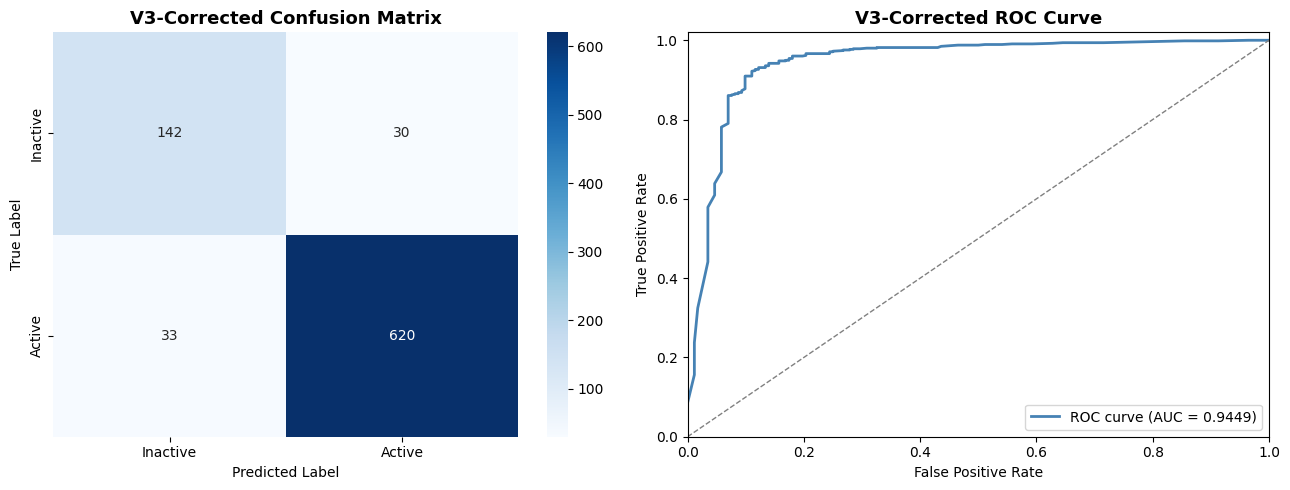

In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# Test Evaluation — auto-selects best available model (V3 > V2)
# ─────────────────────────────────────────────────────────────────────────────
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score,
    f1_score, matthews_corrcoef, average_precision_score,
    precision_score, recall_score, confusion_matrix,
    precision_recall_curve, classification_report, roc_curve,
)

# ── Load best available model ─────────────────────────────────────────────────
_v3_path = 'models/best_finetuned_model_v3.pth'
_v2_path = 'models/best_finetuned_model_v2.pth'
_v3_corr_path = 'models/best_finetuned_model_v3_corrected.pth'

if os.path.exists(_v3_corr_path):
    _model_path  = _v3_corr_path
    _model_label = 'V3-Corrected'
    # Use V3 corrected threshold from training session if available, else find from val set
    _default_thr = best_thr_v3
elif os.path.exists(_v3_path):
    _model_path  = _v3_path
    _model_label = 'V3'
    # Use V3 threshold from training session if available, else find from val set
    _default_thr = best_thr_v3 if 'best_thr_v3' in dir() else 0.5
else:
    _model_path  = _v2_path
    _model_label = 'V2'
    _default_thr = best_thr_v2 if 'best_thr_v2' in dir() else 0.61

print(f"Loading model: {_model_path}")
eval_model = torch.load(_model_path, weights_only=False, map_location=DEVICE)
eval_model.eval()

# ── Build datasets (self-contained) ──────────────────────────────────────────
print("Building evaluation datasets...")
if 'train_ds_v2' not in dir():
    train_ds_v2 = BioActivityDataset_v2(train_df, tokenizer, augment=False)
if 'val_ds_v2' not in dir():
    val_ds_v2 = BioActivityDataset_v2(val_df, tokenizer, scaler=train_ds_v2.scaler)
if 'test_ds_v2' not in dir():
    test_ds_v2 = BioActivityDataset_v2(test_df, tokenizer, scaler=train_ds_v2.scaler)

EVAL_BS = 64
_DEV_TYPE  = DEVICE.type
_AMP_DTYPE = torch.bfloat16 if (USE_AMP and torch.cuda.is_bf16_supported()) else torch.float16

# ── Inference helper ──────────────────────────────────────────────────────────
def get_probs(model, ds, batch_sz=EVAL_BS):
    probs, lbls = [], []
    with torch.no_grad(), torch.amp.autocast(device_type=_DEV_TYPE, dtype=_AMP_DTYPE, enabled=USE_AMP):
        for i in range(0, len(ds), batch_sz):
            logits = model(
                input_ids      = ds.encodings['input_ids'][i:i+batch_sz].to(DEVICE),
                attention_mask = ds.encodings['attention_mask'][i:i+batch_sz].to(DEVICE),
                ecfp           = torch.tensor(ds.ecfp[i:i+batch_sz]).to(DEVICE),
                #maccs          = torch.tensor(ds.maccs[i:i+batch_sz]).to(DEVICE),
                descriptors    = torch.tensor(ds.desc[i:i+batch_sz]).to(DEVICE),
            )
            probs.extend(torch.sigmoid(logits.float()).cpu().numpy())
            lbls.extend(ds.labels[i:i+batch_sz])
    return np.array(probs), np.array(lbls)

# ── Find optimal threshold on validation set ──────────────────────────────────
# print("Finding optimal threshold on validation set...")
# val_probs_e, val_labels_e = get_probs(eval_model, val_ds_v2)
# prec_e, rec_e, thr_e = precision_recall_curve(val_labels_e, val_probs_e)
# f1s_e    = 2 * prec_e * rec_e / (prec_e + rec_e + 1e-8)
# best_thr  = float(thr_e[np.argmax(f1s_e)])
# print(f"Optimal threshold (val F1-maximising): {best_thr:.3f}")

# ── Evaluate on test set ──────────────────────────────────────────────────────
print("\nEvaluating on test set...")
test_probs, test_labels = get_probs(eval_model, test_ds_v2)
test_preds = (test_probs > _default_thr).astype(int)

tn, fp, fn, tp = confusion_matrix(test_labels, test_preds).ravel()
metrics = {
    "Accuracy":     accuracy_score(test_labels, test_preds),
    "Balanced Acc": balanced_accuracy_score(test_labels, test_preds),
    "Precision":    precision_score(test_labels, test_preds, zero_division=0),
    "Recall":       recall_score(test_labels, test_preds, zero_division=0),
    "F1":           f1_score(test_labels, test_preds, zero_division=0),
    "ROC-AUC":      roc_auc_score(test_labels, test_probs),
    "AUPRC":        average_precision_score(test_labels, test_probs),
    "MCC":          matthews_corrcoef(test_labels, test_preds),
    "Sensitivity":  tp / (tp + fn) if (tp + fn) > 0 else 0.0,
    "Specificity":  tn / (tn + fp) if (tn + fp) > 0 else 0.0,
}

print("\n" + "=" * 58)
print(f"  {_model_label} Test-Set Evaluation — FineTunedBERTaECFP_{_model_label}")
print("=" * 58)
for k, v in metrics.items():
    print(f"  {k:<20}: {v:.4f}")
print()
print(classification_report(test_labels, test_preds, target_names=['Inactive', 'Active']))

# ── Confusion Matrix + ROC Curve ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Inactive', 'Active'],
            yticklabels=['Inactive', 'Active'])
axes[0].set_title(f'{_model_label} Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc = roc_auc_score(test_labels, test_probs)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.02])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'{_model_label} ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# K-Fold Cross-Validation Training  (5 folds of V3 architecture)
#
# Why this helps: a single train/val split leaves 4/5 of the data unused
# for model selection. K-fold trains 5 models on different 80%/20% subsets
# of train+val, then ensemble their test predictions → lower variance,
# better generalisation, typically +1-2% AUC over a single model.
#
# Out-of-Fold (OOF) predictions:
#   Each molecule appears as the held-out 20% in exactly one fold.
#   The model for that fold was NEVER trained on it → unbiased predictions.
#   These OOF probabilities are used for threshold selection in the next cell.
#   This is the only statistically valid way to select a threshold when
#   val_df is included in the training pool.
# ─────────────────────────────────────────────────────────────────────────────
import os
from scipy import stats as _sci_stats
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score,
    average_precision_score, matthews_corrcoef, precision_score, recall_score,
    confusion_matrix, cohen_kappa_score, brier_score_loss,
    precision_recall_curve,
)
from torch.utils.data import WeightedRandomSampler
from torch.optim.lr_scheduler import LambdaLR

N_FOLDS   = 5
KF_EPOCHS = 50    # max epochs per fold
KF_PAT    = 12     # early-stopping patience

_DEV_TYPE  = DEVICE.type
_AMP_DTYPE = torch.bfloat16 if (USE_AMP and torch.cuda.is_bf16_supported()) else torch.float16

def _build_llrd_kf(model, base_lr, wd, decay=0.95):
    nd = ['bias', 'LayerNorm.weight', 'LayerNorm.bias']
    g  = []
    hp = [(n, p) for n, p in model.named_parameters()
          if not n.startswith('bert.') and p.requires_grad]
    g += [
        {'params': [p for n, p in hp if not any(x in n for x in nd)], 'lr': base_lr, 'weight_decay': wd},
        {'params': [p for n, p in hp if     any(x in n for x in nd)], 'lr': base_lr, 'weight_decay': 0.0},
    ]
    for d, lyr in enumerate(reversed(list(model.bert.encoder.layer))):
        lr_l = base_lr * (decay ** d)
        lp   = [(n, p) for n, p in lyr.named_parameters() if p.requires_grad]
        if not lp:
            continue
        g += [
            {'params': [p for n, p in lp if not any(x in n for x in nd)], 'lr': lr_l, 'weight_decay': wd},
            {'params': [p for n, p in lp if     any(x in n for x in nd)], 'lr': lr_l, 'weight_decay': 0.0},
        ]
    if hasattr(model.bert, 'embeddings'):
        emb_lr = base_lr * (decay ** len(model.bert.encoder.layer))
        ep = [(n, p) for n, p in model.bert.embeddings.named_parameters() if p.requires_grad]
        if ep:
            g += [
                {'params': [p for n, p in ep if not any(x in n for x in nd)], 'lr': emb_lr, 'weight_decay': wd},
                {'params': [p for n, p in ep if     any(x in n for x in nd)], 'lr': emb_lr, 'weight_decay': 0.0},
            ]
    return optim.AdamW(g)

# ── Combine train + val (test stays held-out forever) ─────────────────────────
dev_df    = pd.concat([train_df, val_df], ignore_index=True)
dev_lbls  = dev_df['bioactivity'].values.astype(int)
print(f"Dev set : {len(dev_df):>5}  ({dev_lbls.sum()} Active, {(dev_lbls==0).sum()} Inactive)")
print(f"Test set: {len(test_df):>5}  (held out — never touched)")
print(f"Plan    : {N_FOLDS} folds × up to {KF_EPOCHS} epochs, collecting OOF predictions\n")

os.makedirs('models', exist_ok=True)

# OOF containers — filled fold by fold, indexed to dev_df positions
_oof_probs_full = np.zeros(len(dev_df), dtype=np.float32)
_oof_lbls_full  = dev_df['bioactivity'].values.astype(int)

skf          = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_paths   = []
fold_scalers = []
fold_aucs    = []

for fold, (tr_idx, vl_idx) in enumerate(skf.split(dev_df, dev_lbls)):
    print(f"\n{'='*58}")
    print(f"  FOLD {fold+1}/{N_FOLDS}  —  train {len(tr_idx)}  |  val(OOF) {len(vl_idx)}")
    print(f"{'='*58}")

    f_tr_df = dev_df.iloc[tr_idx].reset_index(drop=True)
    f_vl_df = dev_df.iloc[vl_idx].reset_index(drop=True)

    f_tr_ds = BioActivityDataset_v2(f_tr_df, tokenizer, augment=True)
    f_vl_ds = BioActivityDataset_v2(f_vl_df, tokenizer, scaler=f_tr_ds.scaler, augment=False)
    fold_scalers.append(f_tr_ds.scaler)

    _fl = f_tr_ds.labels.astype(int)
    _fw = (1.0 / np.bincount(_fl))[_fl]
    _fs = WeightedRandomSampler(torch.tensor(_fw, dtype=torch.float), len(_fw), replacement=True)

    f_tr_ldr = DataLoader(f_tr_ds, batch_size=best_params_v3['batch_size'],
                          sampler=_fs, collate_fn=collate_fn_v2, num_workers=0)
    f_vl_ldr = DataLoader(f_vl_ds, batch_size=best_params_v3['batch_size'] * 2,
                          shuffle=False, collate_fn=collate_fn_v2, num_workers=0)

    f_model = FineTunedBERTaECFP_v3(
        num_heads             = best_params_v3['num_heads'],
        dropout               = best_params_v3['dropout'],
        hidden_dim            = best_params_v3['hidden_dim'],
        num_classifier_layers = best_params_v3['num_classifier_layers'],
        n_cross_layers        = best_params_v3['n_cross_layers'],
        n_pool_layers         = 4,
        freeze_bottom_n       = FREEZE_BOTTOM_N,
    ).to(DEVICE)

    f_opt  = _build_llrd_kf(f_model, BASE_LR_V3, WD_V3, LLRD_FACTOR)
    f_crit = FocalLoss(alpha=0.50, gamma=2.0, smoothing=0.05)
    f_gscl = torch.cuda.amp.GradScaler(enabled=(USE_AMP and _AMP_DTYPE == torch.float16))

    _kf_total   = (len(f_tr_ldr) // GRAD_ACCUM_V3) * KF_EPOCHS
    _kf_warmup  = max(1, int(0.10 * _kf_total))
    def _kf_wc(step):
        if step < _kf_warmup:
            return float(step) / float(_kf_warmup)
        progress = float(step - _kf_warmup) / float(max(1, _kf_total - _kf_warmup))
        return max(1e-7, 0.5 * (1.0 + math.cos(math.pi * progress)))
    f_sch = LambdaLR(f_opt, lr_lambda=_kf_wc)

    
    best_f_auc, f_pat = 0.0, 0
    f_save = f'models/kfold_v3_fold{fold+1}.pth'

    for epoch in range(KF_EPOCHS):
        f_model.train()
        f_opt.zero_grad()

        for bi, batch in enumerate(f_tr_ldr):
            eb = batch['ecfp'].to(DEVICE)
            mb = batch['maccs'].to(DEVICE)
            db = batch['descriptors'].to(DEVICE)
            lb = batch['labels'].float().to(DEVICE)

            with torch.amp.autocast(device_type=_DEV_TYPE, dtype=_AMP_DTYPE, enabled=USE_AMP):
                lg   = f_model(input_ids=batch['input_ids'].to(DEVICE),
                               attention_mask=batch['attention_mask'].to(DEVICE),
                               ecfp=eb, maccs=mb, descriptors=db)
                loss = f_crit(lg, lb) / GRAD_ACCUM_V3

            f_gscl.scale(loss).backward()
            if (bi + 1) % GRAD_ACCUM_V3 == 0:
                f_gscl.unscale_(f_opt)
                torch.nn.utils.clip_grad_norm_(f_model.parameters(), 1.0)
                f_gscl.step(f_opt); f_gscl.update(); f_opt.zero_grad(); f_sch.step()

        f_model.eval()
        vp_l, vl_l = [], []
        with torch.no_grad(), torch.amp.autocast(device_type=_DEV_TYPE, dtype=_AMP_DTYPE, enabled=USE_AMP):
            for vb in f_vl_ldr:
                vl = f_model(input_ids=vb['input_ids'].to(DEVICE),
                             attention_mask=vb['attention_mask'].to(DEVICE),
                             ecfp=vb['ecfp'].to(DEVICE),
                             maccs=vb['maccs'].to(DEVICE),
                             descriptors=vb['descriptors'].to(DEVICE))
                vp_l.extend(torch.sigmoid(vl.float()).cpu().numpy())
                vl_l.extend(vb['labels'].cpu().numpy())

        f_auc = roc_auc_score(vl_l, vp_l)
        print(f"  Ep {epoch+1:02d}/{KF_EPOCHS} | AUC={f_auc:.4f}", end='\r')

        if f_auc > best_f_auc:
            best_f_auc = f_auc; f_pat = 0
            torch.save(f_model, f_save)
        else:
            f_pat += 1
            if f_pat >= KF_PAT:
                print(f"\n  Early stop at epoch {epoch+1}"); break

    print(f"\n  Fold {fold+1} Best AUC: {best_f_auc:.4f}  →  {f_save}")

    # ── Collect OOF predictions (best model, no training on vl_idx) ───────────
    del f_model; torch.cuda.empty_cache()

    _best_fm = torch.load(f_save, weights_only=False, map_location=DEVICE)
    _best_fm.eval()
    _oof_p = []
    with torch.no_grad(), torch.amp.autocast(device_type=_DEV_TYPE, dtype=_AMP_DTYPE, enabled=USE_AMP):
        for _i in range(0, len(f_vl_ds), 64):
            _lg = _best_fm(
                input_ids      = f_vl_ds.encodings['input_ids'][_i:_i+64].to(DEVICE),
                attention_mask = f_vl_ds.encodings['attention_mask'][_i:_i+64].to(DEVICE),
                ecfp           = torch.tensor(f_vl_ds.ecfp[_i:_i+64]).to(DEVICE),
                maccs          = torch.tensor(f_vl_ds.maccs[_i:_i+64]).to(DEVICE),
                descriptors    = torch.tensor(f_vl_ds.desc[_i:_i+64]).to(DEVICE),
            )
            _oof_p.extend(torch.sigmoid(_lg.float()).cpu().numpy())

    _oof_probs_full[vl_idx] = np.array(_oof_p, dtype=np.float32)
    del _best_fm; torch.cuda.empty_cache()

    fold_paths.append(f_save)
    fold_aucs.append(best_f_auc)

print(f"\n{'='*58}")
print(f"K-Fold complete")
print(f"Mean AUC (val)  : {np.mean(fold_aucs):.4f}  ±  {np.std(fold_aucs):.4f}")
print(f"Per-fold        : {[f'{a:.4f}' for a in fold_aucs]}")
print(f"OOF AUC (dev)   : {roc_auc_score(_oof_lbls_full, _oof_probs_full):.4f}  ← unbiased estimate")

# ─────────────────────────────────────────────────────────────────────────────
# K-Fold OOF — Comprehensive Metrics Table
#
# Re-derives the same fold splits (same seed) to slice _oof_probs_full into
# per-fold held-out chunks, computes 13 metrics per fold, then reports
# mean ± std, min, max, and 95% CI (t-distribution, df=N_FOLDS-1).
# ─────────────────────────────────────────────────────────────────────────────

# ── OOF-optimal threshold (maximise F1 on the full OOF set) ──────────────────
_p_oof, _r_oof, _thr_oof = precision_recall_curve(_oof_lbls_full, _oof_probs_full)
_f1s_oof = 2 * _p_oof * _r_oof / np.where((_p_oof + _r_oof) == 0, 1, _p_oof + _r_oof)
_cv_thr  = float(_thr_oof[np.argmax(_f1s_oof[:-1])])
print(f"\nOOF optimal threshold (max-F1): {_cv_thr:.4f}")

# ── Per-fold metric helper ────────────────────────────────────────────────────
def _compute_fold_metrics(probs, labels, thr):
    preds          = (probs >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
    spec           = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    npv_           = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    return {
        'Accuracy'    : accuracy_score(labels, preds),
        'Balanced Acc': balanced_accuracy_score(labels, preds),
        'Precision'   : precision_score(labels, preds, zero_division=0),
        'Recall'      : recall_score(labels, preds, zero_division=0),
        'F1'          : f1_score(labels, preds, zero_division=0),
        'ROC-AUC'     : roc_auc_score(labels, probs),
        'AUPRC'       : average_precision_score(labels, probs),
        'MCC'         : matthews_corrcoef(labels, preds),
        'Sensitivity' : recall_score(labels, preds, zero_division=0),
        'Specificity' : spec,
        'NPV'         : npv_,
        'Cohen s k'   : cohen_kappa_score(labels, preds),
        'Brier'       : brier_score_loss(labels, probs),
    }

# Re-derive fold splits with the same seed → same splits as training
_skf_eval  = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
_fold_stats = []
for _, vl_idx in _skf_eval.split(dev_df, dev_lbls):
    _fold_stats.append(
        _compute_fold_metrics(
            _oof_probs_full[vl_idx],
            _oof_lbls_full[vl_idx],
            _cv_thr,
        )
    )

# ── Aggregate ─────────────────────────────────────────────────────────────────
_metric_keys = list(_fold_stats[0].keys())
_agg = {}
for m in _metric_keys:
    vals  = np.array([f[m] for f in _fold_stats])
    mean  = vals.mean()
    std   = vals.std(ddof=1)
    ci_hw = _sci_stats.t.ppf(0.975, df=N_FOLDS - 1) * std / np.sqrt(N_FOLDS)
    _agg[m] = dict(mean=mean, std=std, min=vals.min(), max=vals.max(),
                   ci_lo=mean - ci_hw, ci_hi=mean + ci_hw)

# ── Full table ────────────────────────────────────────────────────────────────
print("\n" + "=" * 74)
print(f"{'Metric':<14}  {'Mean ± Std':>18}  {'Min':>7}  {'Max':>7}  {'95% CI':>20}")
print("=" * 74)
for m, s in _agg.items():
    print(f"{m:<14}  {s['mean']:.4f} +- {s['std']:.4f}  "
          f"{s['min']:.4f}  {s['max']:.4f}  "
          f"[{s['ci_lo']:.4f}, {s['ci_hi']:.4f}]")
print("=" * 74)

# ── Paper-ready summary ───────────────────────────────────────────────────────
_paper_keys = ['Accuracy', 'ROC-AUC', 'F1', 'MCC', 'AUPRC',
               'Sensitivity', 'Specificity', 'Cohen s k', 'Brier']
print(f"\n  Paper-Ready Summary\n")
print(f"{'':>16}{'Model ('+str(N_FOLDS)+'-Fold CV)'}")
for m in _paper_keys:
    s = _agg[m]
    print(f"{m:<16}  {s['mean']:.4f} +- {s['std']:.4f}")


Dev set :  4669  (3673 Active, 996 Inactive)
Test set:   825  (held out — never touched)
Plan    : 5 folds × up to 50 epochs, collecting OOF predictions


  FOLD 1/5  —  train 3735  |  val(OOF) 934
Computing ECFP...
Computing MACCS...
Computing ECFP...
Computing MACCS...
  Ep 29/50 | AUC=0.9472
  Early stop at epoch 29

  Fold 1 Best AUC: 0.9480  →  models/kfold_v3_fold1.pth

  FOLD 2/5  —  train 3735  |  val(OOF) 934
Computing ECFP...
Computing MACCS...
Computing ECFP...
Computing MACCS...
  Ep 32/50 | AUC=0.9601
  Early stop at epoch 32

  Fold 2 Best AUC: 0.9625  →  models/kfold_v3_fold2.pth

  FOLD 3/5  —  train 3735  |  val(OOF) 934
Computing ECFP...
Computing MACCS...
Computing ECFP...
Computing MACCS...
  Ep 35/50 | AUC=0.9575
  Early stop at epoch 35

  Fold 3 Best AUC: 0.9579  →  models/kfold_v3_fold3.pth

  FOLD 4/5  —  train 3735  |  val(OOF) 934
Computing ECFP...
Computing MACCS...
Computing ECFP...
Computing MACCS...
  Ep 39/50 | AUC=0.9643
  Early stop at epoch 39

  Fold

In [40]:
# ─────────────────────────────────────────────────────────────────────────────
# K-Fold Ensemble — Test Inference & Evaluation  (no TTA)
#
# Threshold selection uses Out-of-Fold (OOF) predictions — NOT val_df.
# Each fold model does a single forward pass on the original test SMILES.
# Final probability = mean across all N_FOLDS models.
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score,
    f1_score, matthews_corrcoef, average_precision_score,
    precision_score, recall_score, confusion_matrix, classification_report,
)

def _batch_infer(model, ds, batch_sz=64):
    model.eval()
    probs = []
    with torch.no_grad(), torch.amp.autocast(device_type=_DEV_TYPE, dtype=_AMP_DTYPE, enabled=USE_AMP):
        for i in range(0, len(ds), batch_sz):
            lg = model(
                input_ids      = ds.encodings['input_ids'][i:i+batch_sz].to(DEVICE),
                attention_mask = ds.encodings['attention_mask'][i:i+batch_sz].to(DEVICE),
                ecfp           = torch.tensor(ds.ecfp[i:i+batch_sz]).to(DEVICE),
                maccs          = torch.tensor(ds.maccs[i:i+batch_sz]).to(DEVICE),
                descriptors    = torch.tensor(ds.desc[i:i+batch_sz]).to(DEVICE),
            )
            probs.extend(torch.sigmoid(lg.float()).cpu().numpy())
    return np.array(probs)

# ── OOF threshold selection (unbiased) ───────────────────────────────────────
print("Selecting threshold from OOF predictions (unbiased)...")
_thrs   = np.linspace(0.10, 0.90, 500)  # fine-grained search for best balanced accuracy
_ba_oof = np.array([
    matthews_corrcoef(_oof_lbls_full, (_oof_probs_full > t).astype(int))
    for t in _thrs
])
kf_thr  = float(_thrs[np.argmax(_ba_oof)])
oof_auc = roc_auc_score(_oof_lbls_full, _oof_probs_full)
print(f"  OOF AUC             : {oof_auc:.4f}")
print(f"  OOF best MCC        : {_ba_oof.max():.4f}  at threshold {kf_thr:.3f}")

# ── Build test dataset (single canonical SMILES per molecule) ─────────────────
_ref_scaler  = fold_scalers[-1]   # fit on ~80% of same data — consistent across folds
test_ds_eval = BioActivityDataset_v2(test_df, tokenizer, scaler=_ref_scaler, augment=False)
print(f"\nTest set: {len(test_ds_eval)} molecules")

# ── Accumulate predictions from all fold models ───────────────────────────────
kf_test_sum = np.zeros(len(test_df))

for i, fpath in enumerate(fold_paths):
    print(f"Fold {i+1}/{N_FOLDS}: {fpath} ...", end='  ')
    fm = torch.load(fpath, weights_only=False, map_location=DEVICE)
    kf_test_sum += _batch_infer(fm, test_ds_eval)
    del fm; torch.cuda.empty_cache()
    print("done.")

kf_test_probs = kf_test_sum / N_FOLDS
kf_test_lbls  = test_df['bioactivity'].values

# ── Final test evaluation ─────────────────────────────────────────────────────
kf_preds           = (kf_test_probs > kf_thr).astype(int)
tn_, fp_, fn_, tp_ = confusion_matrix(kf_test_lbls, kf_preds).ravel()

kf_res = {
    'Accuracy'    : accuracy_score(kf_test_lbls, kf_preds),
    'Balanced Acc': balanced_accuracy_score(kf_test_lbls, kf_preds),
    'Precision'   : precision_score(kf_test_lbls, kf_preds, zero_division=0),
    'Recall'      : recall_score(kf_test_lbls, kf_preds, zero_division=0),
    'F1'          : f1_score(kf_test_lbls, kf_preds, zero_division=0),
    'ROC-AUC'     : roc_auc_score(kf_test_lbls, kf_test_probs),
    'AUPRC'       : average_precision_score(kf_test_lbls, kf_test_probs),
    'MCC'         : matthews_corrcoef(kf_test_lbls, kf_preds),
    'Sensitivity' : tp_ / (tp_ + fn_) if (tp_ + fn_) > 0 else 0.0,
    'Specificity' : tn_ / (tn_ + fp_) if (tn_ + fp_) > 0 else 0.0,
}

print("\n" + "=" * 60)
print(f"  K-Fold ({N_FOLDS}) Ensemble — V3 Architecture (no TTA)")
print(f"  Threshold : {kf_thr:.3f}  (OOF MCC optimal)")
print("=" * 60)
for k, v in kf_res.items():
    print(f"  {k:<22}: {v:.4f}")
print()
print(classification_report(kf_test_lbls, kf_preds, target_names=['Inactive', 'Active']))


Selecting threshold from OOF predictions (unbiased)...
  OOF AUC             : 0.9584
  OOF best MCC        : 0.7899  at threshold 0.483
Computing ECFP...
Computing MACCS...

Test set: 825 molecules
Fold 1/5: models/kfold_v3_fold1.pth ...  done.
Fold 2/5: models/kfold_v3_fold2.pth ...  done.
Fold 3/5: models/kfold_v3_fold3.pth ...  done.
Fold 4/5: models/kfold_v3_fold4.pth ...  done.
Fold 5/5: models/kfold_v3_fold5.pth ...  done.

  K-Fold (5) Ensemble — V3 Architecture (no TTA)
  Threshold : 0.483  (OOF MCC optimal)
  Accuracy              : 0.9236
  Balanced Acc          : 0.8832
  Precision             : 0.9511
  Recall                : 0.9525
  F1                    : 0.9518
  ROC-AUC               : 0.9633
  AUPRC                 : 0.9890
  MCC                   : 0.7681
  Sensitivity           : 0.9525
  Specificity           : 0.8140

              precision    recall  f1-score   support

    Inactive       0.82      0.81      0.82       172
      Active       0.95      0.95    